In [1]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    # Python & NumPy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Random seed set to {seed} for reproducibility.")

set_seed(42)

Random seed set to 42 for reproducibility.



=== TRAIN DATASET (5 Classes) ===
Path: /kaggle/input/datasets/deepthiajith/ricedisease-traindataset/Rice Disease Dataset
  • Brown Spot           | 5388 images
  • Leaf Blast           | 7700 images
  • Leaf Smut            | 1470 images
  • Ragged Stunt Virus   | 85 images
  • Sheath Rot           | 76 images
TOTAL: 14719 images


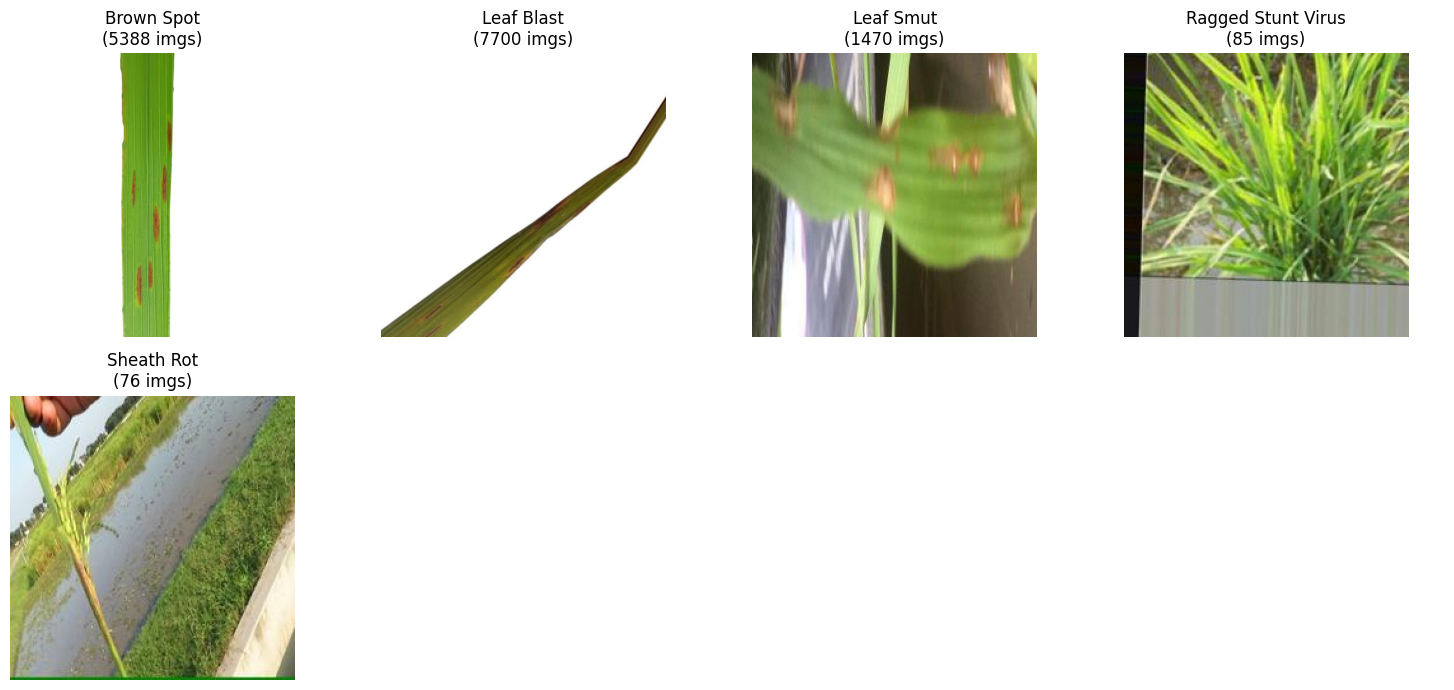


=== TEST DATASET (5 Classes) ===
Path: /kaggle/input/datasets/deepthiajith/ricedisease-testdataset/Rice Disease Dataset Test
  • Brown Spot           | 30 images
  • Leaf Blast           | 30 images
  • Leaf Smut            | 30 images
  • Ragged Stunt Virus   | 15 images
  • Sheath Rot           | 15 images
TOTAL: 120 images


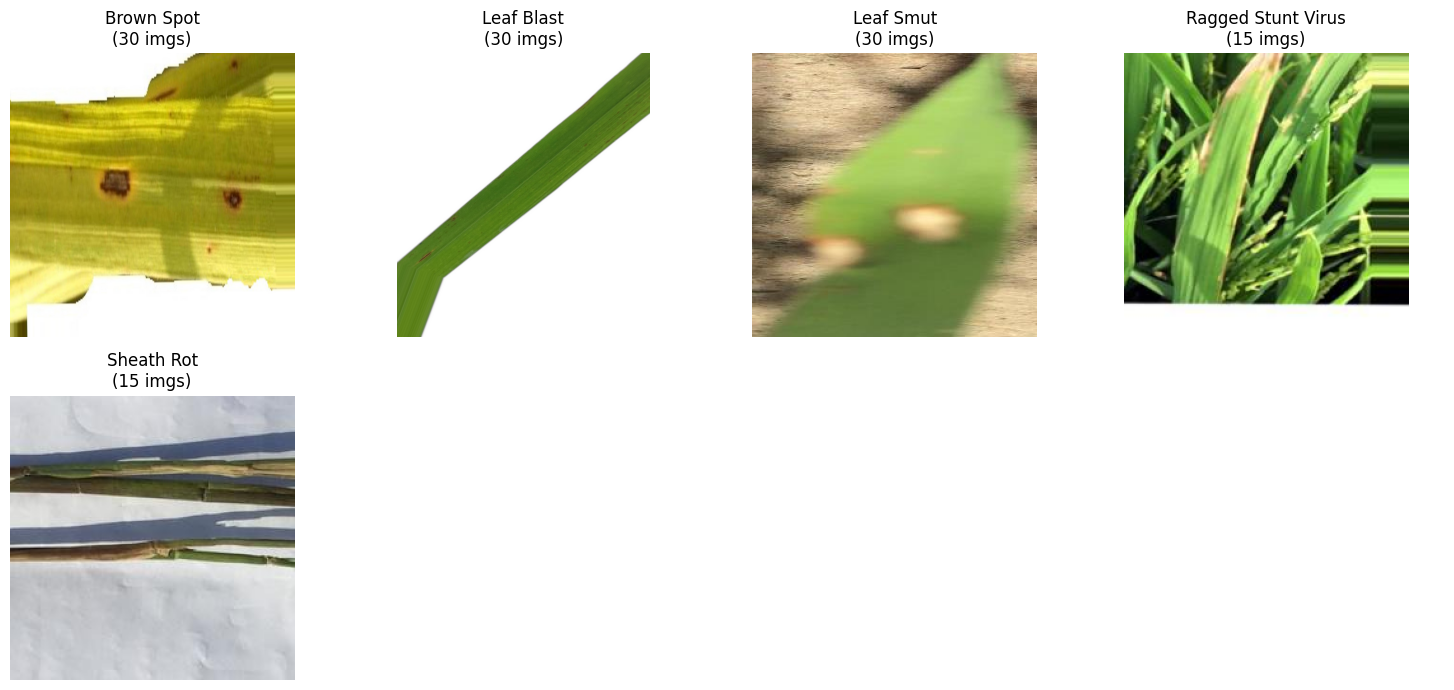

In [3]:
import os
import glob
import cv2
import math
import matplotlib.pyplot as plt

TRAIN_DIR = '/kaggle/input/datasets/deepthiajith/ricedisease-traindataset/Rice Disease Dataset'
TEST_DIR = '/kaggle/input/datasets/deepthiajith/ricedisease-testdataset/Rice Disease Dataset Test'

TARGET_CLASSES = ['sheath rot', 'leaf smut', 'leaf blast', 'ragged stunt virus', 'brown spot']

def inspect_and_plot(data_path, dataset_name):
    if not os.path.exists(data_path):
        # Fallback: sometimes Kaggle unzips without the parent folder
        data_path = data_path.replace('/RiceDisease-TrainDataset', '').replace('/RiceDisease-TestDataset', '')
        if not os.path.exists(data_path):
            print(f"❌ Error: Path not found: {data_path}")
            return

    all_folders = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    classes = sorted([d for d in all_folders if d.lower() in TARGET_CLASSES])
    
    print(f"\n=== {dataset_name.upper()} DATASET ({len(classes)} Classes) ===")
    print(f"Path: {data_path}")
    
    if len(classes) == 0:
        print("❌ Error: None of the target classes were found in this directory!")
        return

    # Setup Grid
    cols = min(4, len(classes))
    rows = math.ceil(len(classes) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    
    # Safely flatten axes array
    if len(classes) > 1 and hasattr(axes, 'flatten'): axes = axes.flatten()
    else: axes = [axes]

    total_images = 0
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(data_path, class_name)
        images = glob.glob(os.path.join(class_path, '*.*')) # Matches jpg, png, etc.
        count = len(images)
        total_images += count
        
        print(f"  • {class_name:<20} | {count} images")

        # Plot first image
        if images:
            img = cv2.imread(images[0])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(f"{class_name}\n({count} imgs)")
        else:
            axes[i].text(0.5, 0.5, "Empty", ha='center')
        
        axes[i].axis('off')

    # Hide unused subplots
    for j in range(len(classes), len(axes)):
        axes[j].axis('off')

    print(f"TOTAL: {total_images} images")
    plt.tight_layout()
    plt.show()

# Run
inspect_and_plot(TRAIN_DIR, "Train")
inspect_and_plot(TEST_DIR, "Test")

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os

class RiceDiseaseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        target_classes = ['sheath rot', 'leaf smut', 'leaf blast', 'ragged stunt virus', 'brown spot']
        all_dirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        
        self.classes = sorted([d for d in all_dirs if d.lower() in target_classes])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        for cls_name in self.classes:
            cls_folder = os.path.join(root_dir, cls_name)
            for img_name in os.listdir(cls_folder):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(cls_folder, img_name))
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load and Split
full_train_dataset = RiceDiseaseDataset(TRAIN_DIR, transform=train_transforms)

# Only split if we actually loaded data
if len(full_train_dataset) == 0:
    raise ValueError("❌ No images loaded! Check if the target classes exist in the directory.")

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])
val_subset.dataset.transform = val_transforms 

test_dataset = RiceDiseaseDataset(TEST_DIR, transform=val_transforms)

# Loaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(full_train_dataset.classes)
print(f"Classes: {full_train_dataset.classes}")
print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}")

Classes: ['Brown Spot', 'Leaf Blast', 'Leaf Smut', 'Ragged Stunt Virus', 'Sheath Rot']
Train: 11775 | Val: 2944 | Test: 120


In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import timm
from tqdm.auto import tqdm
import time
from IPython.display import FileLink, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

class HybridImageClassifier(nn.Module):
    def __init__(self, num_labels):
        super(HybridImageClassifier, self).__init__()
        
        print("Downloading Swin and ViT backbones via timm...")
        # num_classes=0 returns raw feature vectors
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)
        self.swin = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=0)
        
        vit_dim = self.vit.num_features   
        swin_dim = self.swin.num_features 
        
        self.classifier = nn.Linear(vit_dim + swin_dim, num_labels)

    def forward(self, images):
        vit_features = self.vit(images)
        swin_features = self.swin(images)
        
        # Concatenate features and classify
        combined = torch.cat((vit_features, swin_features), dim=1)
        logits = self.classifier(combined)
        return logits

model = HybridImageClassifier(num_classes).to(device)

EPOCHS = 15
LR = 2e-5
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

checkpoint_name = "rice_disease_hybrid_vit_swin.pth"
start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_name):
    print(f"Found checkpoint: '{checkpoint_name}'. Loading...")
    
    checkpoint = torch.load(checkpoint_name, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    if 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
    if 'epoch' in checkpoint:
        start_epoch = checkpoint['epoch'] + 1 
    
    best_acc = checkpoint.get('accuracy', checkpoint.get('best_val_acc', 0.0))
    print(f"Resuming training for Epoch {start_epoch+1} | Previous Best Acc: {best_acc:.2f}%")
else:
    print("No checkpoint found. Starting fresh Hybrid Model Training...")

print(f"\nStarting Hybrid Training (Target: {EPOCHS} Epochs)...")

for epoch in range(start_epoch, EPOCHS):
    start_time = time.time()
    
    # TRAIN
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        
        current_acc = 100 * train_correct / train_total
        loop.set_postfix(loss=loss.item(), acc=f"{current_acc:.1f}%")

    # VALIDATE
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Metrics
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total
    avg_loss = train_loss / train_total
    duration = time.time() - start_time
    
    # Save Best
    saved_tag = ""
    if val_acc > best_acc:
        best_acc = val_acc
        state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'class_names': full_train_dataset.classes,
            'num_classes': num_classes,
            'accuracy': best_acc
        }
        torch.save(state, checkpoint_name)
        saved_tag = " [SAVED]"

    print(f"Ep {epoch+1} | {duration:.0f}s | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%{saved_tag}")
    
    if saved_tag:
        display(FileLink(checkpoint_name))

print(f"\nTraining Complete. Best Validation Accuracy: {best_acc:.2f}%")

final_checkpoint_name = "rice_disease_hybrid_vit_swin_final.pth"

final_state = {
    'epoch': EPOCHS - 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'class_names': full_train_dataset.classes,
    'num_classes': num_classes,
    'accuracy': val_acc
}

torch.save(final_state, final_checkpoint_name)
print(f"✅ Final epoch model saved to: {final_checkpoint_name}")
display(FileLink(final_checkpoint_name))

Device: cuda
No checkpoint found. Starting fresh Hybrid Model Training...

Starting Hybrid Training (Target: 15 Epochs)...


Epoch 1/15:   0%|          | 0/368 [00:00<?, ?it/s]

Ep 1 | 646s | Loss: 0.3334 | Train Acc: 83.4% | Val Acc: 86.1% [SAVED]


/kaggle/working/rice_disease_hybrid_vit_swin.pth

Epoch 2/15:   0%|          | 0/368 [00:00<?, ?it/s]

...

Epoch 15/15:   0%|          | 0/368 [00:00<?, ?it/s]

Ep 15 | 635s | Loss: 0.1448 | Train Acc: 90.1% | Val Acc: 88.8% [SAVED]


/kaggle/working/rice_disease_hybrid_vit_swin.pth


Training Complete. Best Validation Accuracy: 88.79%
✅ Final epoch model saved to: rice_disease_hybrid_vit_swin_final.pth


/kaggle/working/rice_disease_hybrid_vit_swin_final.pth

EVALUATING ON TEST SET
Test Loss: 0.4581
Test Accuracy: 95.00%

DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

        Brown Spot       0.91      1.00      0.95        30
        Leaf Blast       0.94      1.00      0.97        30
         Leaf Smut       0.96      0.90      0.93        30
Ragged Stunt Virus       1.00      0.93      0.97        15
        Sheath Rot       1.00      0.87      0.93        15

          accuracy                           0.95       120
         macro avg       0.96      0.94      0.95       120
      weighted avg       0.95      0.95      0.95       120



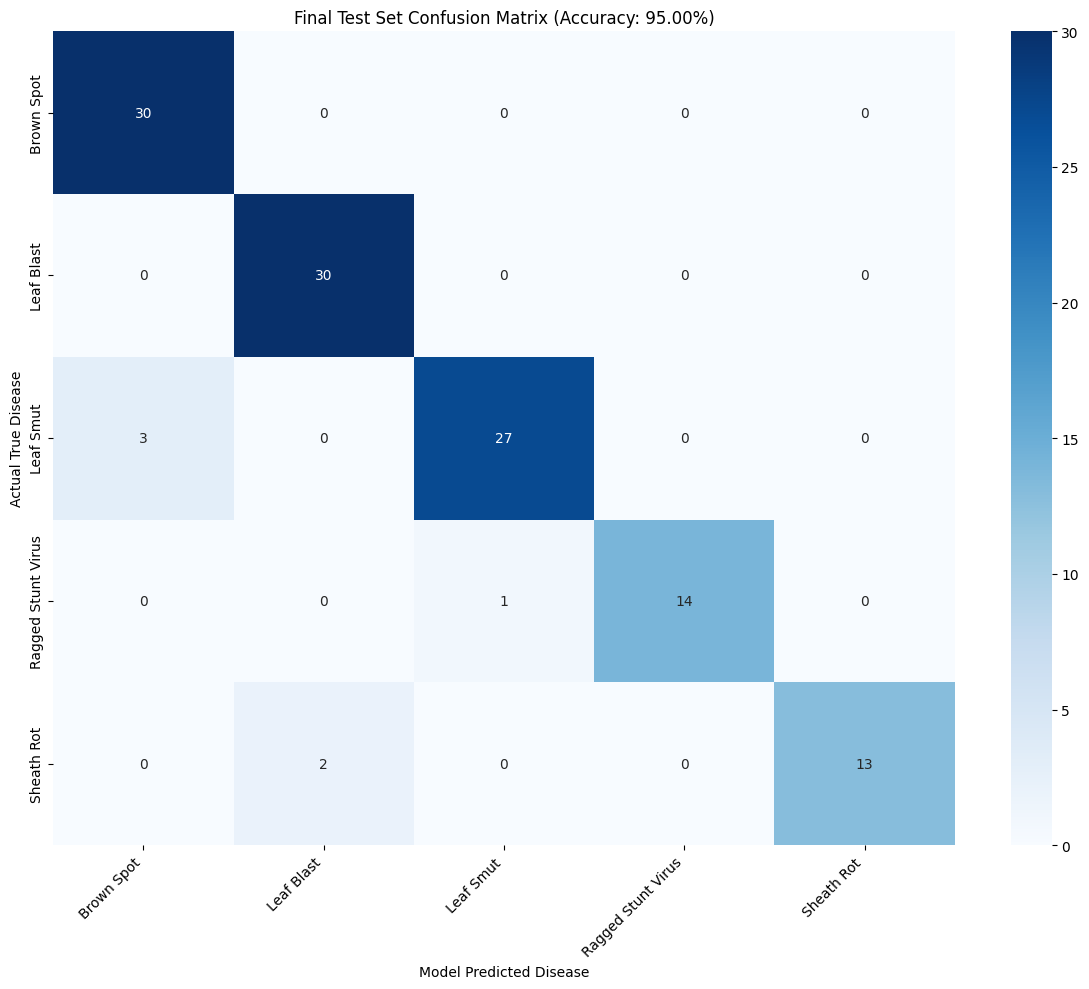

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

print("EVALUATING ON TEST SET")

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        
        # Store for detailed metrics
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate overall metrics
final_test_acc = 100 * test_correct / test_total
final_test_loss = test_loss / test_total

print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.2f}%\n")

class_names = test_dataset.classes

print("DETAILED CLASSIFICATION REPORT")

# Need to check for recall on the minority classes
print(classification_report(all_labels, all_preds, target_names=class_names))


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.ylabel('Actual True Disease')
plt.xlabel('Model Predicted Disease')
plt.title(f'Final Test Set Confusion Matrix (Accuracy: {final_test_acc:.2f}%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
EPOCHS = 30

for epoch in range(15, EPOCHS):
    start_time = time.time()
    
    # TRAIN
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        
        current_acc = 100 * train_correct / train_total
        loop.set_postfix(loss=loss.item(), acc=f"{current_acc:.1f}%")

    # VALIDATE
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Metrics
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total
    avg_loss = train_loss / train_total
    duration = time.time() - start_time
    
    # Save Best
    saved_tag = ""
    if val_acc > best_acc:
        best_acc = val_acc
        state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'class_names': full_train_dataset.classes,
            'num_classes': num_classes,
            'accuracy': best_acc
        }
        torch.save(state, checkpoint_name)
        saved_tag = " [SAVED]"

    print(f"Ep {epoch+1} | {duration:.0f}s | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%{saved_tag}")
    
    if saved_tag:
        display(FileLink(checkpoint_name))

print(f"\nTraining Complete. Best Validation Accuracy: {best_acc:.2f}%")

final_checkpoint_name = "rice_disease_hybrid_vit_swin_final.pth"

final_state = {
    'epoch': EPOCHS - 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'class_names': full_train_dataset.classes,
    'num_classes': num_classes,
    'accuracy': val_acc
}

torch.save(final_state, final_checkpoint_name)
print(f"✅ Final epoch model saved to: {final_checkpoint_name}")
display(FileLink(final_checkpoint_name))

Epoch 16/30:   0%|          | 0/368 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780d4670eca0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780d4670eca0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Ep 16 | 635s | Loss: 0.1443 | Train Acc: 90.3% | Val Acc: 88.4%


Epoch 17/30:   0%|          | 0/368 [00:00<?, ?it/s]

Ep 17 | 634s | Loss: 0.1444 | Train Acc: 90.1% | Val Acc: 87.4%


...

Epoch 29/30:   0%|          | 0/368 [00:00<?, ?it/s]

Ep 29 | 635s | Loss: 0.1428 | Train Acc: 90.1% | Val Acc: 85.8%


Epoch 30/30:   0%|          | 0/368 [00:00<?, ?it/s]

Ep 30 | 633s | Loss: 0.1429 | Train Acc: 90.4% | Val Acc: 86.2%

Training Complete. Best Validation Accuracy: 88.79%
✅ Final epoch model saved to: rice_disease_hybrid_vit_swin_final.pth


/kaggle/working/rice_disease_hybrid_vit_swin_final.pth

EVALUATING ON TEST SET
Test Loss: 0.6963
Test Accuracy: 82.50%

DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

        Brown Spot       0.91      1.00      0.95        30
        Leaf Blast       0.62      1.00      0.77        30
         Leaf Smut       1.00      0.37      0.54        30
Ragged Stunt Virus       1.00      0.93      0.97        15
        Sheath Rot       1.00      0.93      0.97        15

          accuracy                           0.82       120
         macro avg       0.91      0.85      0.84       120
      weighted avg       0.88      0.82      0.81       120



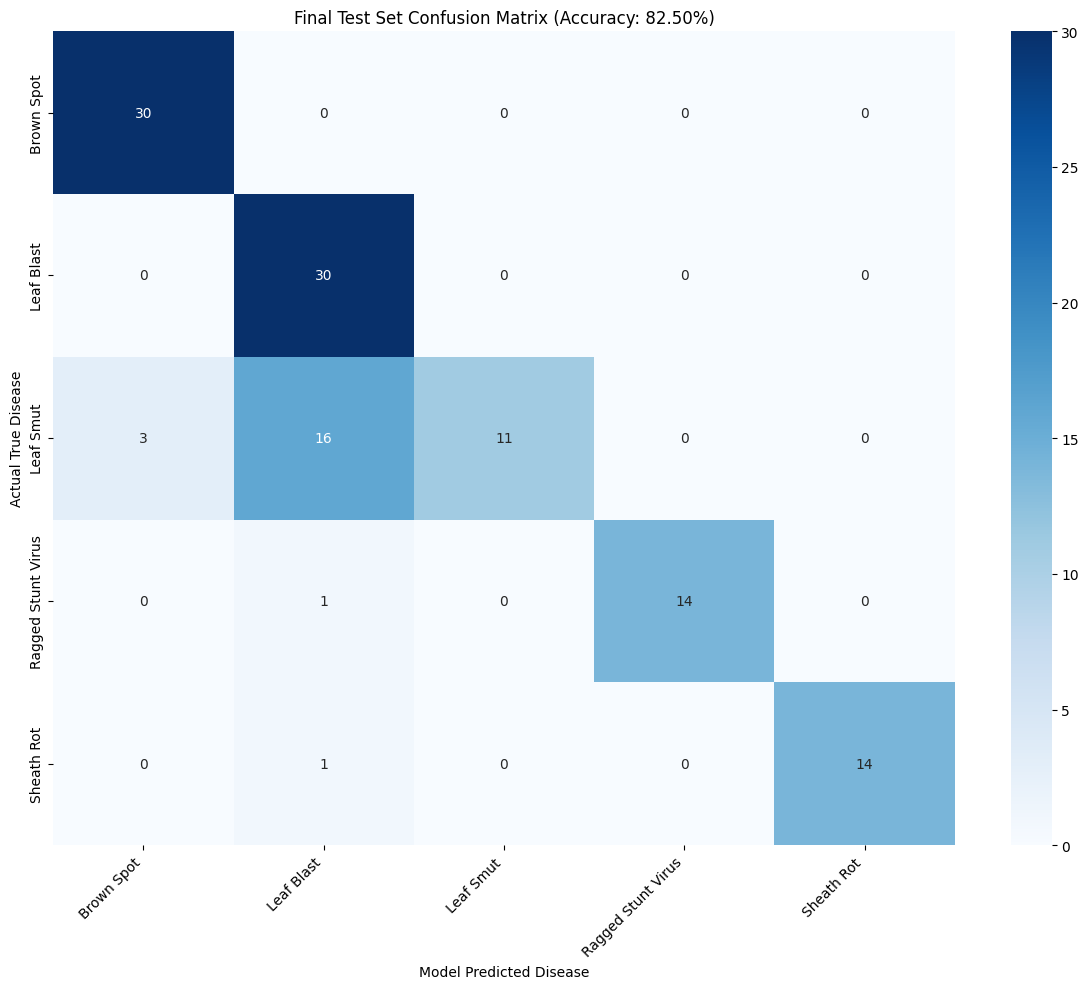

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

print("EVALUATING ON TEST SET")

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        
        # Store for detailed metrics
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate overall metrics
final_test_acc = 100 * test_correct / test_total
final_test_loss = test_loss / test_total

print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.2f}%\n")

class_names = test_dataset.classes

print("DETAILED CLASSIFICATION REPORT")

# Need to check for recall on the minority classes
print(classification_report(all_labels, all_preds, target_names=class_names))


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.ylabel('Actual True Disease')
plt.xlabel('Model Predicted Disease')
plt.title(f'Final Test Set Confusion Matrix (Accuracy: {final_test_acc:.2f}%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()